### E6

In [1]:
import pandas as pd
import numpy as np

accidentes = pd.read_csv("E6_datos/accidentes.csv")
vehiculos = pd.read_csv("E6_datos/vehiculos.csv")

Notemos que la unidad de análisis debe ser el accidente y no el vehículo. Como vehiculos.csv contiene varias filas para un mismo Accident_Index, primero agregamos la información vehicular a nivel de accidente mediante estadísticas resumidas.

In [2]:
def moda(x): # auxiliar para obtener la moda de una serie, devolviendo NaN si no hay moda
    m = x.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

veh_agg = (vehiculos.groupby("Accident_Index").agg(
        n_vehiculos=("Vehicle_Reference", "count"), 
        edad_promedio_vehiculo=("Age_of_Vehicle", "mean"),
        tipo_dominante_vehiculo=("Vehicle_Type", moda),
        presencia_moto=(
            "Vehicle_Type",
            lambda x: x.astype(str)
                       .str.contains("Motorcycle", case=False)
                       .any()
        )
    )
    .reset_index()
)

In [3]:
veh_agg

,Accident_Index,n_vehiculos,edad_promedio_vehiculo,tipo_dominante_vehiculo,presencia_moto
0,2016010000005,2,4.0,Motorcycle 50cc and under,True
1,2016010000006,1,1.0,Car,False
2,2016010000008,1,5.0,Car,False
3,2016010000016,1,7.0,Bus or coach (17 or more pass seats),False
4,2016010000018,2,11.0,Car,False
...,...,...,...,...,...
136616,2016984130916,2,9.5,Car,False
136617,2016984131116,2,14.0,Car,False
136618,2016984131216,1,NaN,Goods 7.5 tonnes mgw and over,False
136619,2016984131316,1,13.0,Car,False


Lo bueno es que ahí ya calza con las rows del csv de accidentes. Así, después de la agregación obtenemos una fila por accidente, lo que permite combinar esta información con accidentes.csv mediante Accident_Index

Ahora la idea es convertir la hora, notemos que es un string. Algo que busqué que sirve harto es usar una especie de representación circular de la hora, usando seno y coseno. Esto es porque la hora 23 y la hora 0 son cercanas, pero si las representamos como números, no lo son.

In [4]:
hora = pd.to_datetime(accidentes["Time"], format="%H:%M", errors="coerce")

h = hora.dt.hour + hora.dt.minute / 60

accidentes["hora_sin"] = np.sin(2 * np.pi * h / 24)
accidentes["hora_cos"] = np.cos(2 * np.pi * h / 24)

accidentes["fin_semana"] = (accidentes["Day_of_Week"].isin(["Saturday", "Sunday"]).astype(int))

Seleccionamos variables que representen dimensiones temporales, espaciales, viales, ambientales y vehiculares. Se excluyen variables identificadoras y aquellas reservadas como variables de contraste, que mostraremos luego.

In [5]:
tabla = accidentes[[
    "Accident_Index",

    # temporal
    "hora_sin",
    "hora_cos",
    "fin_semana",

    # espacial
    "Latitude",
    "Longitude",
    "Urban_or_Rural_Area",

    # vial
    "Road_Type",
    "Speed_limit",
    "Junction_Detail",
    "Road_Surface_Conditions",

    # ambiental
    "Light_Conditions",
    "Weather_Conditions"
]].copy()

Y ahora podemos juntar la tabla de accidentes con la de vehículos agregada, usando un merge. Notemos que el merge es por Accident_Index, que es la columna que nos permite unir las dos tablas.

In [6]:
tabla = tabla.merge(veh_agg, on="Accident_Index", how="left")
tabla.head()

,Accident_Index,hora_sin,hora_cos,fin_semana,Latitude,Longitude,Urban_or_Rural_Area,Road_Type,Speed_limit,Junction_Detail,Road_Surface_Conditions,Light_Conditions,Weather_Conditions,n_vehiculos,edad_promedio_vehiculo,tipo_dominante_vehiculo,presencia_moto
0,2016010000005,0.608761,0.793353,0,51.584754,-0.279323,Urban,Single carriageway,30.0,Not at junction or within 20 metres,Dry,Darkness - lights unlit,Fine no high winds,2,4.0,Motorcycle 50cc and under,True
1,2016010000006,0.160743,0.986996,0,51.449595,0.184928,Urban,Single carriageway,30.0,Other junction,Dry,Darkness - lights lit,Fine no high winds,1,1.0,Car,False
2,2016010000008,0.362438,0.932008,0,51.543563,-0.473837,Urban,Roundabout,30.0,Roundabout,Dry,Darkness - lights lit,Fine no high winds,1,5.0,Car,False
3,2016010000016,0.659346,-0.751840,0,51.404958,-0.164442,Urban,Single carriageway,30.0,T or staggered junction,Dry,Daylight,Fine no high winds,1,7.0,Bus or coach (17 or more pass seats),False
4,2016010000018,0.880891,-0.473320,0,51.483139,-0.406580,Urban,Dual carriageway,40.0,Not at junction or within 20 metres,Dry,Daylight,Fine no high winds,2,11.0,Car,False


Reservamos la severidad, el número de víctimas y la asistencia policial como variables de contraste. Estas no se utilizan para construir la representación no supervisada, pero podrán utilizarse posteriormente para interpretar los patrones encontrados.

In [7]:
contraste = accidentes[[
    "Accident_Index",
    "Accident_Severity",
    "Number_of_Casualties",
    "Did_Police_Officer_Attend_Scene_of_Accident"
]].copy()

Finalmente preparamos la tabla para aprendizaje no supervisado: imputamos valores faltantes, estandarizamos las variables numéricas y codificamos las variables categóricas.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Elegimos variables numéricas y categóricas

In [9]:
numericas = [
    "hora_sin",
    "hora_cos",
    "fin_semana",
    "Latitude",
    "Longitude",
    "Speed_limit",
    "n_vehiculos",
    "edad_promedio_vehiculo"
]

categoricas = [
    "Urban_or_Rural_Area",
    "Road_Type",
    "Junction_Detail",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Weather_Conditions",
    "tipo_dominante_vehiculo",
    "presencia_moto"
]

Utilizamos un ColumnTransformer para aplicar el tratamiento correspondiente a variables numéricas y categóricas.

In [10]:
preprocesador = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numericas
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]),
        categoricas
    )
])

In [11]:
X = preprocesador.fit_transform(tabla)

X = pd.DataFrame(X, columns=preprocesador.get_feature_names_out(), index=tabla["Accident_Index"])

X.shape

(136621, 73)

Perfecto, es lo esperado.

In [12]:
print(f"Valores faltantes en X: {X.isna().sum().sum()}")

Valores faltantes en X: 0


Tenemos nuestro X listo.

A modo de resumen, se construyó una representación con una fila por accidente e información temporal, espacial, vial, ambiental y vehicular.

La información de vehículos fue agregada previamente a nivel de accidente mediante cantidad de vehículos, edad promedio, tipo dominante y presencia de motocicletas. La hora se representó mediante seno y coseno para respetar su naturaleza cíclica.

La severidad, el número de víctimas y la asistencia policial se reservaron como variables de contraste y no participaron en la representación no supervisada.

A partir de 16 variables seleccionadas, la imputación, estandarización y codificación categórica produjeron una matriz final de 136.621 accidentes y 73 variables, sin valores faltantes, lista para reducción de dimensionalidad y clustering.

### Misión 2

Primero aplicamos PCA con dos componentes para obtener una representación bidimensional que permita visualizar la estructura global de los accidentes

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(
    "Varianza explicada:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

Varianza explicada: 0.264


Las dos primeras componentes explican un 26,4% de la varianza total. Por lo tanto, esta proyección es útil para visualizar patrones generales, pero no representa toda la estructura del espacio original, como pueden intuir.

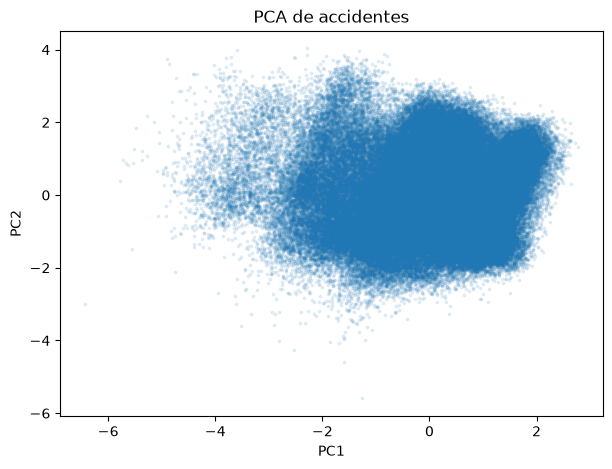

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=3, alpha=0.1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA de accidentes")
plt.show()

La proyección no muestra grupos discretos claramente separados, sino una estructura principalmente continua y con alta superposición. Para interpretar esta forma, analizamos cómo se distribuyen distintas variables contextuales sobre el plano.

Definimos una función para graficar más rápido en base a la variable.

In [15]:
def plot_pca(variable):
    plt.figure(figsize=(7, 5))

    for valor in tabla[variable].dropna().unique():
        mask = tabla[variable] == valor

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=3,
            alpha=0.2,
            label=str(valor)
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(variable)
    plt.legend()
    plt.show()


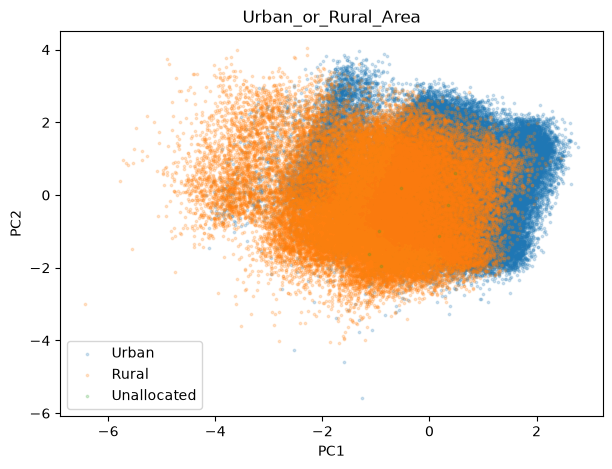

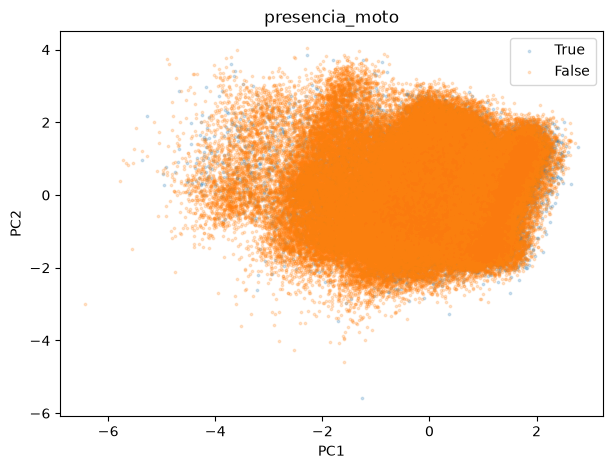

In [16]:
plot_pca("Urban_or_Rural_Area")
plot_pca("presencia_moto")

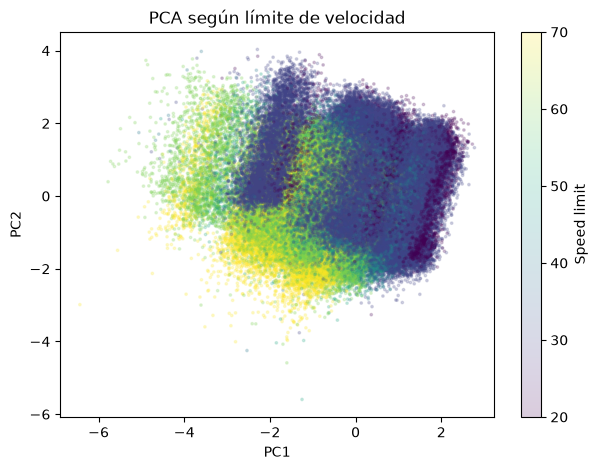

In [17]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=tabla["Speed_limit"],
    s=3,
    alpha=0.2
)

plt.colorbar(label="Speed limit")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA según límite de velocidad")
plt.show()

La proyección PCA muestra que la estructura está asociada especialmente a variables espaciales y viales. 

Los accidentes urbanos y rurales presentan una distribución diferente, aunque con una superposición considerable. 

El límite de velocidad también presenta un patrón claro sobre las primeras componentes. En cambio, la presencia de motocicletas no genera una separación global evidente en esta proyección.

Así, podemos decir que las dos primeras componentes capturan principalmente diferencias relacionadas con el contexto territorial y vial, aunque el 26,4% de varianza explicada limita la interpretación del espacio completo.

Además de la proyección bidimensional, construimos una representación PCA que conserve el 90% de la varianza para utilizarla en análisis posteriores.

In [18]:
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X)

print(
    X.shape[1],
    "->",
    X_pca_90.shape[1],
    "componentes"
)

73 -> 14 componentes


Para complementar PCA utilizamos t-SNE, que permite explorar relaciones locales entre accidentes. Debido al tamaño del conjunto completo, se utiliza una muestra aleatoria reproducible de 10.000 accidentes para reducir el costo computacional y facilitar la visualización.

Las distancias globales entre regiones de una proyección t-SNE deben interpretarse con cautela, por lo que nos enfocamos principalmente en patrones y vecindarios locales.

In [19]:
from sklearn.manifold import TSNE

rng = np.random.default_rng(0)

idx_sample = rng.choice(len(X), size=10000, replace=False)

X_sample = X.iloc[idx_sample]
tabla_sample = tabla.iloc[idx_sample]

In [20]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0
)

X_tsne = tsne.fit_transform(X_sample)

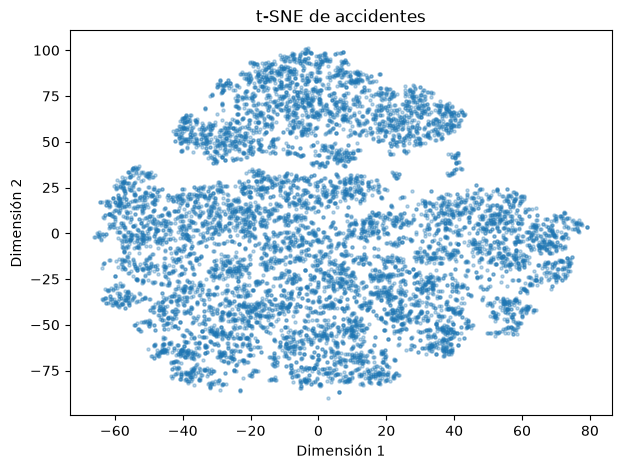

In [21]:
plt.figure(figsize=(7, 5))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, alpha=0.3)

plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("t-SNE de accidentes")
plt.show()

In [22]:
def plot_tsne(variable):
    plt.figure(figsize=(7, 5))

    for valor in tabla_sample[variable].dropna().unique():
        mask = tabla_sample[variable] == valor

        plt.scatter(
            X_tsne[mask, 0],
            X_tsne[mask, 1],
            s=3,
            alpha=0.2,
            label=str(valor)
        )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(variable)
    plt.legend()
    plt.show()


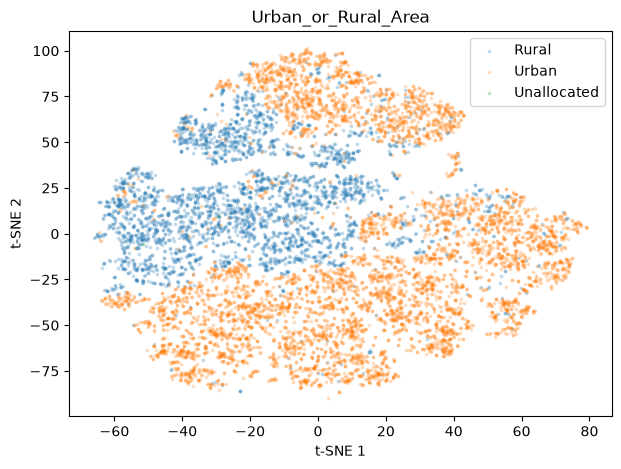

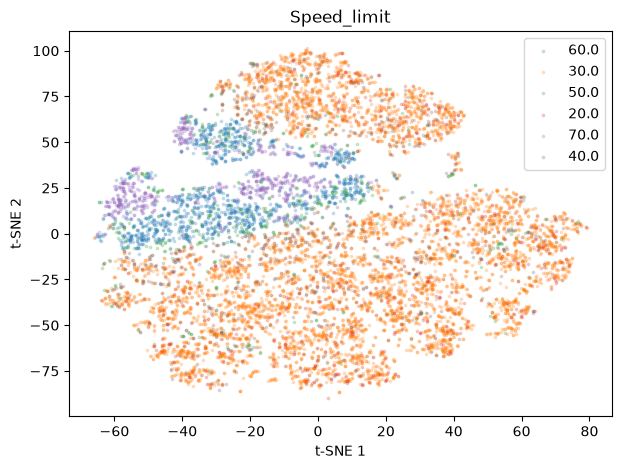

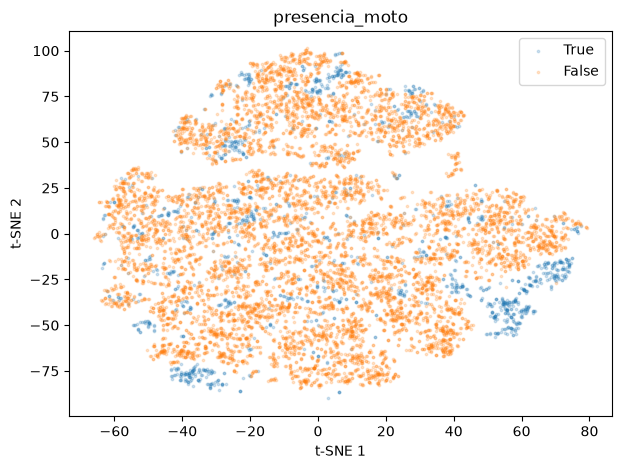

In [23]:
plot_tsne("Urban_or_Rural_Area")
plot_tsne("Speed_limit")
plot_tsne("presencia_moto")

t-SNE muestra una estructura local más marcada que la proyección PCA. Se observan regiones predominantemente urbanas o rurales, aunque con zonas de superposición. El límite de velocidad presenta también una organización local clara, con regiones dominadas por determinados valores.

La presencia de motocicletas no separa globalmente la representación, pero sí aparece concentrada en algunos sectores, lo que ayuda a pensar que existen perfiles locales de accidentes donde este tipo de vehículo es más frecuente.

Tenemos entonces que PCA y t-SNE indican que la estructura de los accidentes está especialmente relacionada con características espaciales y viales, mientras que algunas características vehiculares aparecen asociadas a regiones más locales. Para los análisis posteriores se conservará la representación PCA de 14 componentes, que mantiene el 90% de la varianza.

### Misión 3

Vamos a usar K-means sobre la representación PCA de 14 componentes. Probaremos distintas cantidades de clusters y se evaluará mediante inercia y silhouette. Debido al tamaño del conjunto, silhouette se calcula sobre una muestra aleatoria de 10.000 accidentes (similar a lo que hicimos con t-SNE).

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 9):

    modelo = KMeans(n_clusters=k, n_init=10, random_state=0)

    labels = modelo.fit_predict(X_pca_90)

    resultados.append({
        "k": k,
        "inercia": modelo.inertia_,
        "silhouette": silhouette_score(
            X_pca_90,
            labels,
            sample_size=10000,
            random_state=0
        )
    })

resultados = pd.DataFrame(resultados)
resultados

,k,inercia,silhouette
0,2,1.241946e+06,0.163509
1,3,1.126359e+06,0.116753
2,4,1.048465e+06,0.113159
3,5,9.813742e+05,0.116846
4,6,9.414739e+05,0.111915
5,7,9.074999e+05,0.108875
6,8,8.798660e+05,0.111705


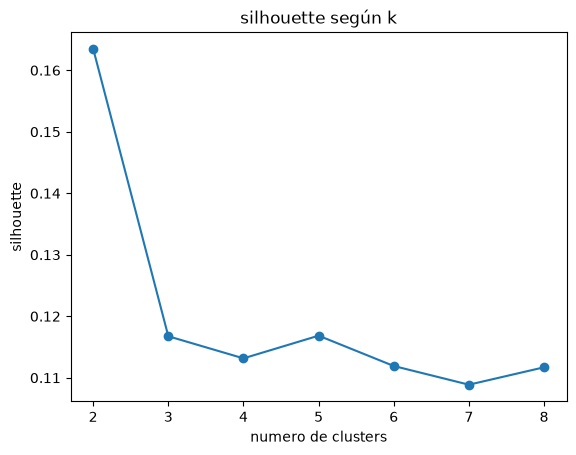

In [25]:
plt.plot(resultados["k"], resultados["silhouette"], marker="o")
plt.xlabel("numero de clusters")
plt.ylabel("silhouette")
plt.title("silhouette según k")
plt.show()

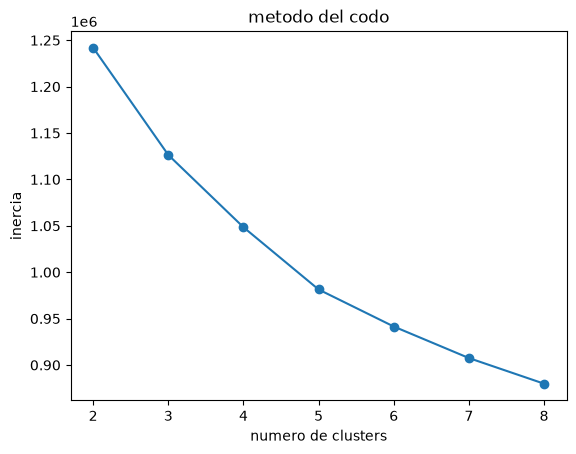

In [26]:
plt.plot(resultados["k"], resultados["inercia"], marker="o")
plt.xlabel("numero de clusters")
plt.ylabel("inercia")
plt.title("metodo del codo")
plt.show()

La mejor configuración según silhouette corresponde a k=2, aunque en realidad el valor obtenido es relativamente bajo, lo que implicaría que la estructura de los accidentes es continua y que los grupos presentan cierto solapamiento. 

El método del codo tampoco muestra una separación evidente para valores mayores de k, por lo que seleccionamos k=2 como la solución más simple y mejor respaldada por las métricas.

In [27]:
k_final = 2

modelo_final = KMeans(n_clusters=k_final, n_init=10, random_state=0)

clusters = modelo_final.fit_predict(X_pca_90)

resultado = tabla.copy()
resultado["cluster"] = clusters

In [28]:
resultado["cluster"].value_counts().sort_index()

cluster
0     35057
1    101564
Name: count, dtype: int64

Ahora podemos hacer una caracterización de las tipologías

In [29]:
resultado.groupby("cluster")[
    [
        "Speed_limit",
        "fin_semana",
        "n_vehiculos",
        "edad_promedio_vehiculo",
        "presencia_moto"
    ]
].mean().round(2)

,Speed_limit,fin_semana,n_vehiculos,edad_promedio_vehiculo,presencia_moto
cluster,,,,,
0,59.87,0.26,1.98,8.41,0.12
1,30.37,0.23,1.80,8.12,0.15


In [30]:
resultado.groupby("cluster")[
    [
        "Urban_or_Rural_Area",
        "Road_Type",
        "Light_Conditions",
        "Weather_Conditions"
    ]
].agg(moda)

,Urban_or_Rural_Area,Road_Type,Light_Conditions,Weather_Conditions
cluster,,,,
0,Rural,Single carriageway,Daylight,Fine no high winds
1,Urban,Single carriageway,Daylight,Fine no high winds


El cluster 0 representa principalmente accidentes en contextos rurales y vías de mayor velocidad, con un límite promedio cercano a 60 mph. El cluster 1 concentra principalmente accidentes urbanos y de menor velocidad, con un límite promedio cercano a 30 mph.

Las diferencias en número de vehículos, antigüedad vehicular, ocurrencia durante fines de semana y presencia de motocicletas son menores, por lo que la principal distinción entre ambas tipologías parece estar asociada al contexto espacial y vial.

Notemos que la moda de tipo de vía, iluminación y clima coincide entre ambos grupos, por lo que estas variables no permiten diferenciarlos claramente mediante esta síntesis.

Podemos también identificar accidentes atípicos.

In [31]:
distancias = modelo_final.transform(X_pca_90)

resultado["distancia_centro"] = distancias[
    np.arange(len(resultado)),
    clusters
]

Utilizamos la distancia al centroide como medida de atipicidad. Para facilitar la interpretación, clasificamos operacionalmente como atípico al 5% de accidentes más alejados del centro de cada cluster.

In [32]:
resultado["atipico"] = (
    resultado
    .groupby("cluster")["distancia_centro"]
    .transform(lambda x: x >= x.quantile(0.95))
)

resultado["atipico"].value_counts()

atipico
False    129789
True       6832
Name: count, dtype: int64

In [33]:
resultado.groupby("atipico")[
    [
        "Speed_limit",
        "n_vehiculos",
        "edad_promedio_vehiculo",
        "presencia_moto"
    ]
].mean().round(2)

,Speed_limit,n_vehiculos,edad_promedio_vehiculo,presencia_moto
atipico,,,,
False,37.96,1.82,8.08,0.14
True,37.60,2.34,10.29,0.17


In [34]:
pd.crosstab(
    resultado["atipico"],
    resultado["Urban_or_Rural_Area"],
    normalize="index"
).round(3)

Urban_or_Rural_Area,Rural,Unallocated,Urban
atipico,,,
False,0.348,0.0,0.652
True,0.430,0.0,0.570


In [35]:
pd.crosstab(
    resultado["atipico"],
    resultado["Road_Type"],
    normalize="index"
).round(3)

Road_Type,Data missing or out of range,Dual carriageway,One way street,Roundabout,Single carriageway,Slip road,Unknown
atipico,,,,,,,
False,0.0,0.146,0.023,0.064,0.746,0.011,0.01
True,0.0,0.175,0.026,0.072,0.708,0.008,0.01


Los accidentes atípicos presentan, en promedio, más vehículos involucrados, vehículos de mayor antigüedad y una presencia ligeramente mayor de motocicletas. Además, muestran una mayor proporción de accidentes rurales y en vías de doble calzada.

En cambio, el límite de velocidad promedio es prácticamente igual entre accidentes típicos y atípicos, por lo que esta variable parece distinguir mejor las tipologías generales que los casos extremos dentro de cada grupo.

Ahora rescatamos las variables de contraste.

In [36]:
resultado = resultado.merge(
    contraste,
    on="Accident_Index",
    how="left"
)

In [37]:
pd.crosstab(
    resultado["cluster"],
    resultado["Accident_Severity"],
    normalize="index"
).round(3)

Accident_Severity,Fatal,Serious,Slight
cluster,,,
0,0.028,0.198,0.774
1,0.007,0.145,0.847


In [38]:
pd.crosstab(
    resultado["atipico"],
    resultado["Accident_Severity"],
    normalize="index"
).round(3)

Accident_Severity,Fatal,Serious,Slight
atipico,,,
False,0.012,0.157,0.831
True,0.023,0.203,0.773


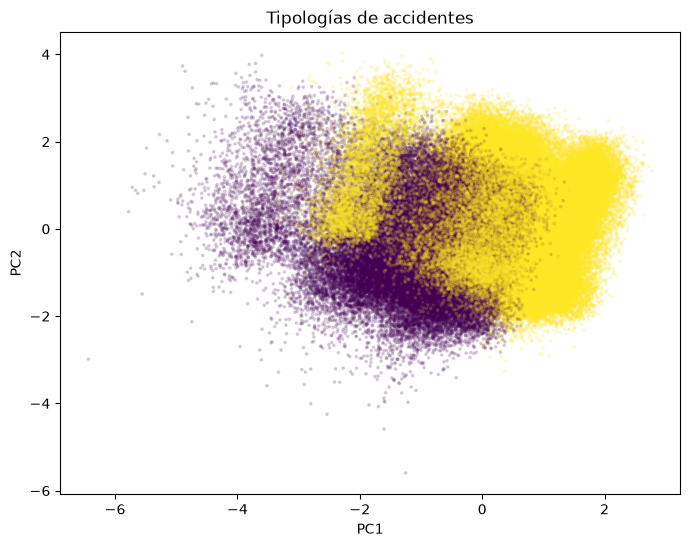

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=3,
    alpha=0.15
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Tipologías de accidentes")
plt.show()

A modo de síntesis, la solución seleccionada utiliza K-means con k=2 sobre la representación PCA de 14 componentes. Aunque el silhouette obtenido es relativamente bajo, k=2 presenta el mejor valor entre las configuraciones evaluadas y el método del codo no entrega evidencia clara para utilizar una división más compleja.

Las tipologías obtenidas distinguen principalmente un perfil rural y de mayor velocidad y otro urbano y de menor velocidad. La severidad, reservada como variable de contraste, muestra que el primer grupo presenta una mayor proporción de accidentes graves y fatales.

La distancia al centroide se utilizó como medida de atipicidad y se clasificó como atípico al 5% más distante dentro de cada cluster. Estos casos presentan más vehículos involucrados, mayor antigüedad vehicular, una proporción mayor de accidentes rurales y una mayor frecuencia de severidad grave o fatal.

### Misión 4

Se utiliza la severidad como variable objetivo para construir un modelo supervisado simple. Esta variable fue reservada desde la Misión 1 y no participó en la construcción de la representación, los clusters ni la medida de atipicidad. Como vemos, el objetivo no es maximizar el desempeño predictivo, sino analizar si la dificultad de predicción cambia entre las tipologías y los casos atípicos identificados previamente.

Notemos que como X ya contiene solo variables de contexto y no incluye severidad, podemos reutilizarlo para lo que se viene

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score

y = (contraste.set_index("Accident_Index").loc[X.index, "Accident_Severity"])

info = (resultado.set_index("Accident_Index").loc[X.index, ["cluster", "atipico"]])

train_idx, test_idx = train_test_split(
    X.index,
    test_size=0.2,
    random_state=0,
    stratify=y
)

Ahora hacemos un modelo supervisado simple

In [41]:
modelo_sup = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

modelo_sup.fit(
    X.loc[train_idx],
    y.loc[train_idx]
)

pred = modelo_sup.predict(X.loc[test_idx])

Como las clases están desbalanceadas, no usaremos accuracy sola.

In [42]:
print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            y.loc[test_idx],
            pred
        ),
        3
    )
)

print(
    "F1 macro:",
    round(
        f1_score(
            y.loc[test_idx],
            pred,
            average="macro"
        ),
        3
    )
)

Balanced accuracy: 0.506
F1 macro: 0.352


Ahora, compararemos desempeño de clusters

In [43]:
evaluacion = info.loc[test_idx].copy()

evaluacion["real"] = y.loc[test_idx]
evaluacion["pred"] = pred

Una función para facilitar la comparación

In [44]:
def metricas(grupo):
    return pd.Series({
        "balanced_accuracy": balanced_accuracy_score(
            grupo["real"],
            grupo["pred"]
        ),
        "f1_macro": f1_score(
            grupo["real"],
            grupo["pred"],
            average="macro"
        )
    })

In [45]:
evaluacion.groupby("cluster").apply(metricas)

,balanced_accuracy,f1_macro
cluster,,
0,0.412959,0.215833
1,0.469039,0.381142


En general podemos ver que el modelo se comporta mucho mejor (o sea, le es más fácil predecir severidad) en el cluster 1 que en cluster 0. Fijémonos en que el perfil del 0 es rural y de mayor velocidad, mientras que el del 1 es urbano y de menor velocidad. Como una posible explicación, fuera del alcance del ejercicio, el mejor desempeño en el cluster urbano y de menor velocidad podría relacionarse con que en este grupo los accidentes graves son menos frecuentes y presentan patrones más regulares. Sin embargo, este análisis no permite establecer la causa de esta diferencia.

Del mismo modo se puede hacer para atípicos

In [46]:
evaluacion.groupby("atipico").apply(metricas)

,balanced_accuracy,f1_macro
atipico,,
False,0.504848,0.351744
True,0.492004,0.337386


La diferencia de desempeño entre accidentes típicos y atípicos es pequeña, mientras que las diferencias entre clusters son más marcadas. Esto puede implicar que la tipología del accidente está más asociada a cambios en la dificultad de predicción que la atipicidad medida dentro de cada grupo.

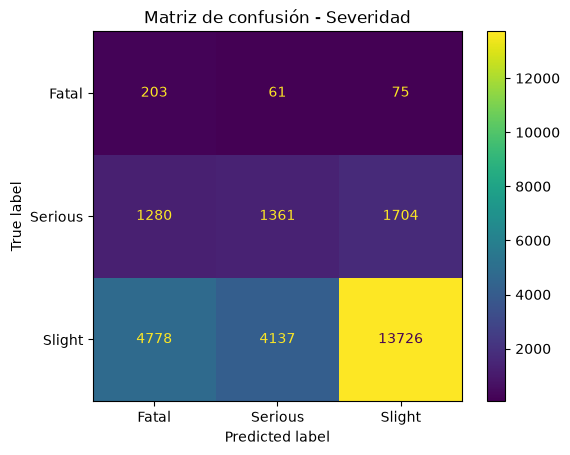

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    evaluacion["real"],
    evaluacion["pred"]
)

plt.title("Matriz de confusión - Severidad")
plt.show()

La matriz de confusión nos muestra además mayor dificultad para distinguir los accidentes fatales y graves respecto de los accidentes leves.

Así, para finalizar, el análisis supervisado respalda que las estructuras encontradas mediante aprendizaje no supervisado son relevantes: las tipologías presentan diferencias tanto en distribución de severidad como en desempeño predictivo. Los casos atípicos también muestran una ligera mayor dificultad de modelamiento, aunque este efecto es menor.